Parsing the Raw PDN File

The dataset (OCA 2.0) is not a clean CSV — it's a raw PDN (Portable Draughts Notation)
text file, the standard format used to record checkers/draughts games, similar to PGN
for chess. Each game is stored as a block of metadata tags (Event, Date, Black, White,
Result) followed by a sequence of moves in algebraic notation.

Since no pre-built parser exists for this exact format, I wrote a custom regex-based
parser to extract structured data from the raw text. This step converts 22,621
unstructured game records into a clean, analysis-ready pandas DataFrame.


In [3]:
import re
import pandas as pd

def parse_pdn(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        content = f.read()


    raw_games = re.split(r'\n(?=\[Event)', content.strip())  # Split into individual games by blank line before [Event

    games = []
    for raw in raw_games:
        game = {}


        for tag in ['Event', 'Date', 'Black', 'White', 'Result', 'Site', 'Round']:   # Extract metadata tags
            match = re.search(rf'\[{tag}\s+"([^"]+)"\]', raw)
            game[tag] = match.group(1) if match else None


        moves_raw = re.sub(r'\[[^\]]+\]', '', raw).strip()   # Extract move sequence — everything after the last metadata tag


        moves_clean = re.sub(r'\d+\.', '', moves_raw)        # Remove move numbers (e.g. "1." "2." etc)


        moves_clean = re.sub(r'(1-0|0-1|1/2-1/2)\s*$', '', moves_clean).strip() # Remove result token at end (0-1, 1-0, 1/2-1/2)


        move_list = moves_clean.split()       # Split into individual moves

        game['moves']       = move_list
        game['game_length'] = len(move_list)


        game['opening']     = ' '.join(move_list[:6]) if len(move_list) >= 6 else ' '.join(move_list)


        game['black_first'] = move_list[0] if len(move_list) > 0 else None
        game['white_first'] = move_list[1] if len(move_list) > 1 else None


        game['captures']    = sum(1 for m in move_list if 'x' in m)

        # Aggression score — captures per move
        game['aggression']  = round(game['captures'] / game['game_length'], 4) if game['game_length'] > 0 else 0


        year_match          = re.search(r'(\d{4})', game['Date']) if game['Date'] else None
        game['year']        = int(year_match.group(1)) if year_match else None
        game['decade']      = (game['year'] // 10) * 10 if game['year'] else None

        games.append(game)

    df = pd.DataFrame(games)


    result_map = {'1-0': 'White', '0-1': 'Black', '1/2-1/2': 'Draw'}
    df['outcome'] = df['Result'].map(result_map)


    df = df[df['outcome'].notna() & (df['game_length'] > 0)].reset_index(drop=True)

    return df



df = parse_pdn('OCA_2.0.txt')

print(f"Total games parsed : {len(df)}")
print(f"Columns            : {list(df.columns)}")
print(f"\nOutcome distribution:\n{df['outcome'].value_counts()}")
print(f"\nDate range         : {df['year'].min()} – {df['year'].max()}")
print(f"Avg game length    : {df['game_length'].mean():.1f} moves")
print(f"Avg captures/game  : {df['captures'].mean():.1f}")
print(f"\nSample rows:")
print(df[['Event','Black','White','outcome','game_length','captures','aggression','year']].head(10))

Total games parsed : 22621
Columns            : ['Event', 'Date', 'Black', 'White', 'Result', 'Site', 'Round', 'moves', 'game_length', 'opening', 'black_first', 'white_first', 'captures', 'aggression', 'year', 'decade', 'outcome']

Outcome distribution:
outcome
Draw     14192
Black     4803
White     3626
Name: count, dtype: int64

Date range         : 1841 – 2004
Avg game length    : 51.2 moves
Avg captures/game  : 13.5

Sample rows:
                    Event         Black         White outcome  game_length  \
0         Manchester 1841  Moorhead, W.    Wyllie, J.   Black           44   
1             Alwick 1842       Hay, W.    Wyllie, J.    Draw           52   
2    Carluke 1844, game 1  Anderson, A.    Wyllie, J.   Black           22   
3    Carluke 1844, game 2  Anderson, A.    Wyllie, J.    Draw           40   
4  Edinburgh 1847, game 1    Wyllie, J.  Anderson, A.    Draw           67   
5  Edinburgh 1847, game 2  Anderson, A.    Wyllie, J.   White           41   
6  Edinburgh 18

**Exploratory Data Analysis**

Before building any model, it's important to understand the dataset's structure and
any historical patterns hidden in 163 years of recorded games (1841–2004).

**Questions I wanted to answer:**
1. How balanced are the three outcomes (Black win / White win / Draw)?
2. Has the draw rate changed over time — has the game become more "solved" or
   defensive as theory advanced?
3. Do drawn games tend to last longer than decisive ones?
4. Which opening moves are most common, and do any show a clear win-rate advantage?
5. Who are the strongest historical players by win rate?

This EDA directly informed feature engineering in Phase 3 — for example, the strong
imbalance toward draws (63%) is why I used macro F1 instead of accuracy as my primary
evaluation metric later on.

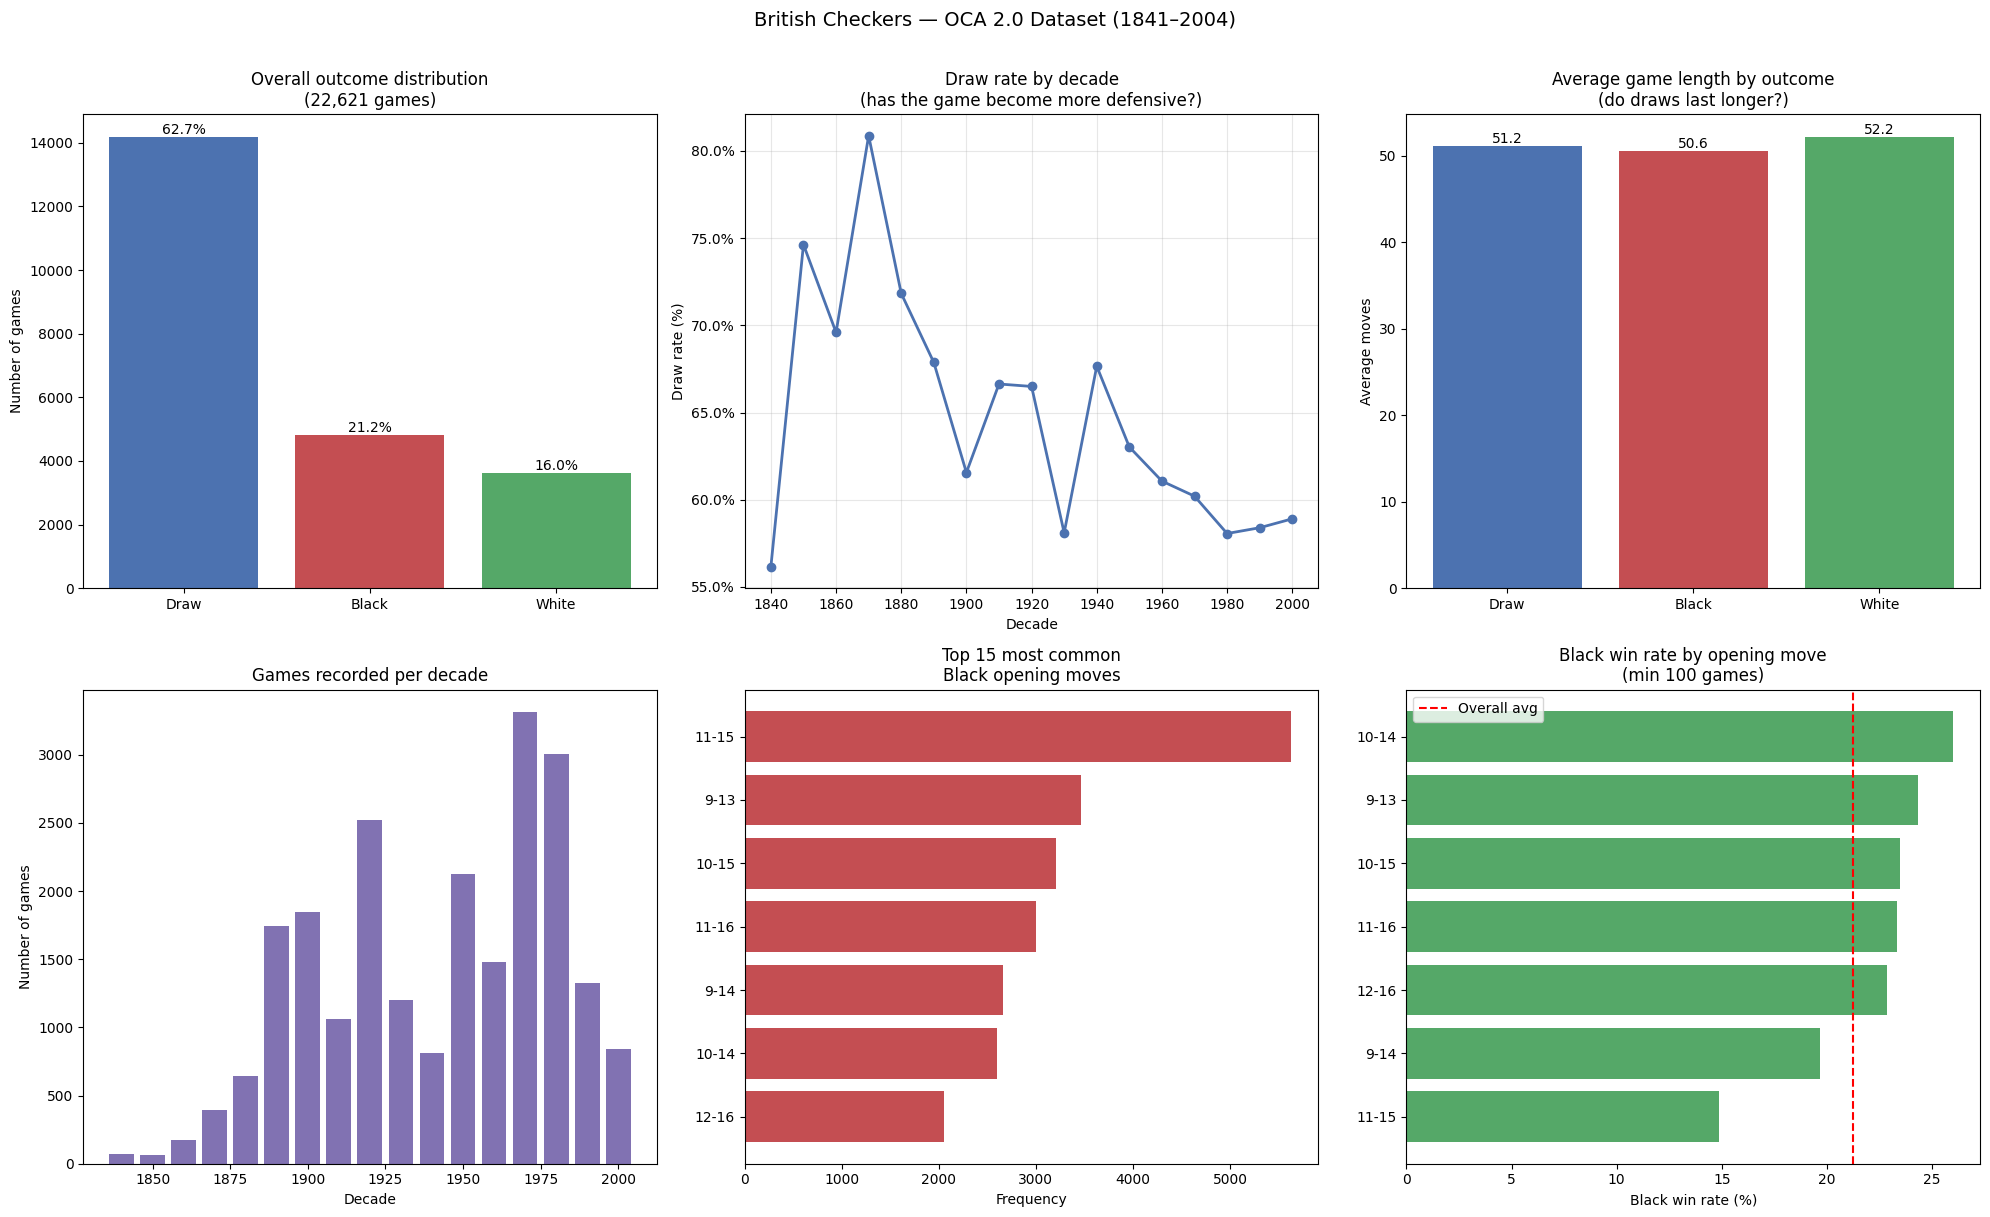


===== TOP 10 PLAYERS BY WIN RATE (min 30 games as Black) =====
        Black  games  wins  win_rate
     Wold, K.   68.0  44.0      64.7
  Milhado, W.   35.0  21.0      60.0
McKenna, C.A.   35.0  18.0      51.4
   Landry, T.   36.0  16.0      44.4
  Shields, D.   37.0  16.0      43.2
  Bassett, J.   59.0  25.0      42.4
 Buckby, G.F.   33.0  14.0      42.4
  Fondren, P.   60.0  25.0      41.7
    Young, C.   42.0  17.0      40.5
    Owen, HL.   38.0  15.0      39.5


In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

#  Overall outcome distribution
outcome_counts = df['outcome'].value_counts()
colors = {'Draw': '#4C72B0', 'Black': '#C44E52', 'White': '#55A868'}
axes[0, 0].bar(outcome_counts.index,
               outcome_counts.values,
               color=[colors[o] for o in outcome_counts.index])
axes[0, 0].set_title('Overall outcome distribution\n(22,621 games)')
axes[0, 0].set_ylabel('Number of games')
for i, (val, count) in enumerate(zip(outcome_counts.index, outcome_counts.values)):
    axes[0, 0].text(i, count + 100, f'{count/len(df)*100:.1f}%',
                    ha='center', fontsize=10)

#  Draw rate by decade
decade_df = df[df['decade'].notna()].copy()
decade_stats = decade_df.groupby('decade').apply(
    lambda x: pd.Series({
        'draw_rate'  : (x['outcome'] == 'Draw').mean() * 100,
        'game_count' : len(x)
    })
).reset_index()
decade_stats = decade_stats[decade_stats['game_count'] >= 5]

axes[0, 1].plot(decade_stats['decade'], decade_stats['draw_rate'],
                marker='o', color='#4C72B0', linewidth=2)
axes[0, 1].set_title('Draw rate by decade\n(has the game become more defensive?)')
axes[0, 1].set_xlabel('Decade')
axes[0, 1].set_ylabel('Draw rate (%)')
axes[0, 1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0, 1].grid(alpha=0.3)

#  Average game length by outcome
avg_length = df.groupby('outcome')['game_length'].mean().reindex(['Draw', 'Black', 'White'])
axes[0, 2].bar(avg_length.index, avg_length.values,
               color=[colors[o] for o in avg_length.index])
axes[0, 2].set_title('Average game length by outcome\n(do draws last longer?)')
axes[0, 2].set_ylabel('Average moves')
for i, val in enumerate(avg_length.values):
    axes[0, 2].text(i, val + 0.3, f'{val:.1f}', ha='center', fontsize=10)

# Game volume by decade
axes[1, 0].bar(decade_stats['decade'], decade_stats['game_count'],
               color='#8172B2', width=8)
axes[1, 0].set_title('Games recorded per decade')
axes[1, 0].set_xlabel('Decade')
axes[1, 0].set_ylabel('Number of games')

#  Top 15 most common opening moves (black first move)
top_openings = df['black_first'].value_counts().head(15)
axes[1, 1].barh(top_openings.index[::-1], top_openings.values[::-1], color='#C44E52')
axes[1, 1].set_title('Top 15 most common\nBlack opening moves')
axes[1, 1].set_xlabel('Frequency')

#  Win rate by opening move (min 100 games)
opening_stats = df.groupby('black_first').apply(
    lambda x: pd.Series({
        'black_win_rate': (x['outcome'] == 'Black').mean() * 100,
        'count'         : len(x)
    })
).reset_index()
opening_stats = opening_stats[opening_stats['count'] >= 100].sort_values('black_win_rate', ascending=True)

axes[1, 2].barh(opening_stats['black_first'], opening_stats['black_win_rate'], color='#55A868')
axes[1, 2].set_title('Black win rate by opening move\n(min 100 games)')
axes[1, 2].set_xlabel('Black win rate (%)')
axes[1, 2].axvline(df['outcome'].eq('Black').mean() * 100,
                   color='red', linestyle='--', label='Overall avg')
axes[1, 2].legend()

plt.suptitle('British Checkers — OCA 2.0 Dataset (1841–2004)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top players
print("\n===== TOP 10 PLAYERS BY WIN RATE (min 30 games as Black) =====")
player_stats = df.groupby('Black').apply(
    lambda x: pd.Series({
        'games'   : len(x),
        'wins'    : (x['outcome'] == 'Black').sum(),
        'win_rate': round((x['outcome'] == 'Black').mean() * 100, 1)
    })
).reset_index()
player_stats = player_stats[player_stats['games'] >= 30].sort_values('win_rate', ascending=False)
print(player_stats.head(10).to_string(index=False))

 Feature Engineering

Raw move sequences cannot be fed directly into a machine learning model — they need
to be converted into numerical features. I engineered features across two categories:

**1. Game dynamics features**
- `game_length` — total number of moves, a rough proxy for game complexity
- `captures` — total number of capture moves
- `aggression` — captures normalised by game length (captures per move), since longer
  games naturally have more captures even if the player isn't more aggressive

**2. Player experience features**
- `black_experience` / `white_experience` — number of games each player had played
  *before* this particular match, computed by sorting all games chronologically and
  tracking a running count per player
- `exp_diff` — experience gap between the two opponents

This required care to avoid data leakage: experience must only count *prior* games,
never future ones, which is why the dataset is sorted by year before this loop runs.

**3. Opening move encoding**
- The first move played by Black and White is label-encoded into a numeric feature,
  allowing the model to learn whether certain opening moves correlate with specific
  outcomes

In [5]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# ── 3a. Basic features (already in df from Phase 1) ──────────────────────────
# game_length, captures, aggression, decade, year — already computed

# ── 3b. Player experience feature ────────────────────────────────────────────
# How many games had each player played BEFORE this game?
df = df.sort_values('year').reset_index(drop=True)

black_exp, white_exp = {}, {}
black_exp_list, white_exp_list = [], []

for _, row in df.iterrows():
    b, w = row['Black'], row['White']
    black_exp_list.append(black_exp.get(b, 0))
    white_exp_list.append(white_exp.get(w, 0))
    black_exp[b] = black_exp.get(b, 0) + 1
    white_exp[w] = white_exp.get(w, 0) + 1

df['black_experience'] = black_exp_list
df['white_experience'] = white_exp_list
df['exp_diff']         = df['black_experience'] - df['white_experience']

# ── 3c. Opening move encoding ─────────────────────────────────────────────────
le = LabelEncoder()
df['black_first_enc'] = le.fit_transform(df['black_first'].fillna('unknown'))
df['white_first_enc'] = le.fit_transform(df['white_first'].fillna('unknown'))

# ── 3d. Assemble final feature matrix ─────────────────────────────────────────
X = df[['game_length', 'captures', 'aggression',
        'black_experience', 'white_experience', 'exp_diff',
        'black_first_enc', 'white_first_enc']].copy()
X['decade'] = df['decade'].fillna(df['decade'].median())

y = df['outcome']

print(f"Feature matrix shape : {X.shape}")
print(f"Features used        : {list(X.columns)}")
print(f"\nTarget distribution:\n{y.value_counts()}")

Feature matrix shape : (22621, 9)
Features used        : ['game_length', 'captures', 'aggression', 'black_experience', 'white_experience', 'exp_diff', 'black_first_enc', 'white_first_enc', 'decade']

Target distribution:
outcome
Draw     14192
Black     4803
White     3626
Name: count, dtype: int64


**Game Outcome Prediction**

**Goal:** predict the outcome of a game (Black win / White win / Draw) using game
dynamics and player experience features — not the full move sequence, which would
leak the answer.

**Why three models?**
I compared Logistic Regression (simple, interpretable baseline), Random Forest
(handles non-linear feature interactions), and XGBoost (typically state-of-the-art
for tabular data) to see which approach best captures the relationship between game
dynamics, player experience, and outcome.

**Why macro F1 instead of accuracy?**
The dataset is heavily imbalanced — 63% of games are draws. A model that always
predicts "Draw" would achieve 63% accuracy while being completely useless. Macro F1
averages the F1 score across all three classes equally, forcing the model to perform
reasonably on the minority classes (Black win, White win) too.

**Train / validation / test split (70/15/15):**
- Train set — used to fit each model
- Validation set — used to compare the three models fairly and select the best one
- Test set — used only once, at the end, to report final unbiased performance


Train size     : 15834
Validation size: 3393
Test size      : 3394

========== VALIDATION RESULTS ==========

--- Logistic Regression ---
Macro F1 : 0.4640
              precision    recall  f1-score   support

       Black       0.35      0.46      0.40       720
        Draw       0.76      0.58      0.66      2129
       White       0.28      0.42      0.34       544

    accuracy                           0.53      3393
   macro avg       0.46      0.49      0.46      3393
weighted avg       0.59      0.53      0.55      3393


--- Random Forest ---
Macro F1 : 0.4337
              precision    recall  f1-score   support

       Black       0.52      0.26      0.34       720
        Draw       0.67      0.91      0.77      2129
       White       0.40      0.12      0.18       544

    accuracy                           0.64      3393
   macro avg       0.53      0.43      0.43      3393
weighted avg       0.60      0.64      0.59      3393


--- XGBoost ---
Macro F1 : 0.4793
      

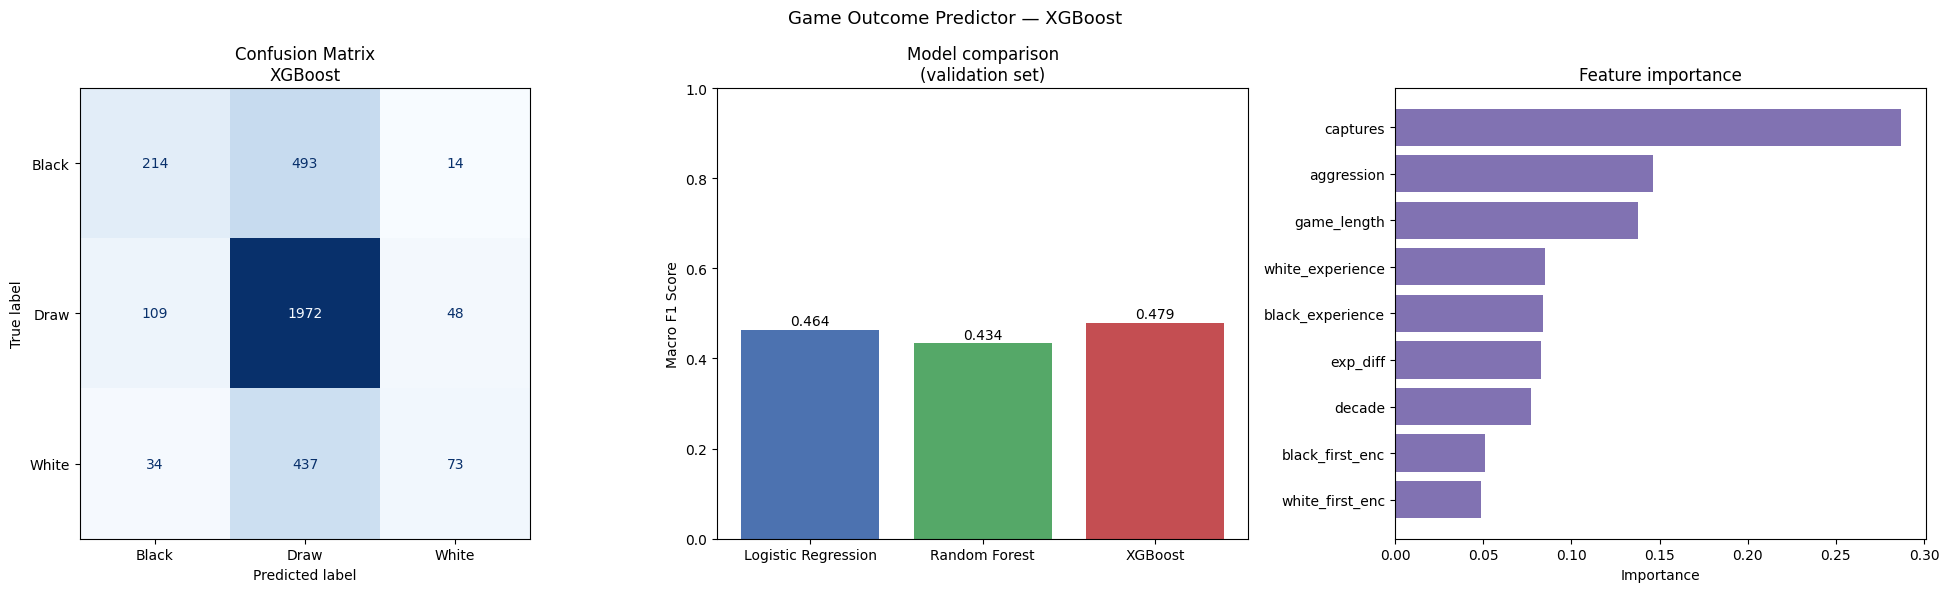


Done.


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── 4a. Split ─────────────────────────────────────────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train size     : {len(X_train)}")
print(f"Validation size: {len(X_val)}")
print(f"Test size      : {len(X_test)}")

# ── 4b. Train 3 models ────────────────────────────────────────────────────────
le_outcome  = LabelEncoder()
y_train_enc = le_outcome.fit_transform(y_train)
y_val_enc   = le_outcome.transform(y_val)
y_test_enc  = le_outcome.transform(y_test)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000,
                                               class_weight='balanced',
                                               random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100,
                                                   class_weight='balanced',
                                                   random_state=42),
    'XGBoost'            : XGBClassifier(n_estimators=200,
                                          max_depth=5,
                                          learning_rate=0.05,
                                          use_label_encoder=False,
                                          eval_metric='mlogloss',
                                          random_state=42)
}

print("\n========== VALIDATION RESULTS ==========")
val_scores = {}
for name, model in models.items():
    model.fit(X_train, y_train_enc)
    y_val_pred = model.predict(X_val)

    report = classification_report(y_val_enc, y_val_pred,
                                    target_names=le_outcome.classes_,
                                    output_dict=True)
    macro_f1 = report['macro avg']['f1-score']
    val_scores[name] = macro_f1

    print(f"\n--- {name} ---")
    print(f"Macro F1 : {macro_f1:.4f}")
    print(classification_report(y_val_enc, y_val_pred,
                                 target_names=le_outcome.classes_))

best_name  = max(val_scores, key=val_scores.get)
best_model = models[best_name]
print(f"\nBest model: {best_name} (Macro F1 = {val_scores[best_name]:.4f})")

# ── 4c. Final test evaluation ─────────────────────────────────────────────────
print("\n========== FINAL TEST RESULTS ==========")
y_test_pred = best_model.predict(X_test)

print(f"Model    : {best_name}")
print(classification_report(y_test_enc, y_test_pred,
                             target_names=le_outcome.classes_))

# ── 4d. Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test_enc, y_test_pred,
    display_labels=le_outcome.classes_,
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title(f'Confusion Matrix\n{best_name}')

# Model comparison
axes[1].bar(val_scores.keys(), val_scores.values(),
            color=['#4C72B0', '#55A868', '#C44E52'])
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('Macro F1 Score')
axes[1].set_title('Model comparison\n(validation set)')
for i, (k, v) in enumerate(val_scores.items()):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

# Feature importance — now just the 9 real features, fully readable
if best_name in ['Random Forest', 'XGBoost']:
    importances = best_model.feature_importances_
    feat_names  = list(X.columns)
    sorted_idx  = np.argsort(importances)
    axes[2].barh([feat_names[i] for i in sorted_idx],
                 importances[sorted_idx], color='#8172B2')
    axes[2].set_title('Feature importance')
    axes[2].set_xlabel('Importance')
else:
    axes[2].axis('off')
    axes[2].text(0.5, 0.5, 'Feature importance\nnot available for\nLogistic Regression',
                 ha='center', va='center', fontsize=12)

plt.suptitle(f'Game Outcome Predictor — {best_name}', fontsize=13)
plt.tight_layout()
plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDone.")